# 05. Churn Modeling

Experiment notebook for building, visualizing, training, and evaluating binary churn prediction models before promotion to production.

Target definition: `churn = 1` when a customer has zero valid purchases in the 3-month evaluation period; otherwise `churn = 0`.

## 0. Setup & Configuration

Load dependencies, configure reproducibility, and read the silver transaction layer. The temporal split is anchored to the shifted maximum invoice date so relative observation and evaluation windows stay intact.

In [1]:
from __future__ import annotations

import glob
import time
import warnings
from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:,.4f}".format)

RANDOM_STATE = 42
TEST_SIZE = 0.2
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

CONFIG = {
    "silver_glob": str(PROJECT_ROOT / "data" / "silver" / "year_month=*" / "data_silver.parquet"),
    "sample_frac": None,
}


def load_silver_transactions(config: dict) -> pd.DataFrame:
    files = sorted(glob.glob(config["silver_glob"]))
    if not files:
        raise FileNotFoundError(
            f"No silver parquet files found. Update CONFIG['silver_glob']: {config['silver_glob']}"
        )

    frame = pd.concat((pd.read_parquet(path) for path in files), ignore_index=True)
    frame["invoice_date"] = pd.to_datetime(frame["invoice_date"])
    frame["customer_id"] = frame["customer_id"].astype("string")

    sample_frac = config.get("sample_frac")
    if sample_frac:
        frame = frame.sample(frac=sample_frac, random_state=RANDOM_STATE).reset_index(drop=True)

    return frame


df = load_silver_transactions(CONFIG)
SHIFTED_MAX_DATE = df["invoice_date"].max()
OBSERVATION_END = SHIFTED_MAX_DATE - timedelta(days=90)
EVALUATION_START = OBSERVATION_END + timedelta(days=1)

print(f"Rows loaded: {len(df):,}")
print(f"Customers loaded: {df['customer_id'].nunique():,}")
print(f"Shifted max invoice date: {SHIFTED_MAX_DATE:%Y-%m-%d}")
print(f"Observation period: {df['invoice_date'].min():%Y-%m-%d} to {OBSERVATION_END:%Y-%m-%d}")
print(f"Evaluation period: {EVALUATION_START:%Y-%m-%d} to {SHIFTED_MAX_DATE:%Y-%m-%d}")


display(df.head(30))
print(df.shape)

Rows loaded: 1,008,442
Customers loaded: 5,922
Shifted max invoice date: 2026-06-05
Observation period: 2024-06-02 to 2026-03-07
Evaluation period: 2026-03-08 to 2026-06-05


,invoice,stock_code,description,quantity,price,customer_id,country,is_cancellation,line_amount,invoice_date,original_invoice_date,invoice_year,invoice_month,invoice_day,invoice_quarter,invoice_day_of_week,invoice_week,year_month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0000,6.9500,13085,United Kingdom,False,83.4000,2024-06-02 07:45:00,2009-12-01 07:45:00,2024,6,2,2,6,22,2024-06
1,489434,79323P,PINK CHERRY LIGHTS,12.0000,6.7500,13085,United Kingdom,False,81.0000,2024-06-02 07:45:00,2009-12-01 07:45:00,2024,6,2,2,6,22,2024-06
2,489434,79323W,WHITE CHERRY LIGHTS,12.0000,6.7500,13085,United Kingdom,False,81.0000,2024-06-02 07:45:00,2009-12-01 07:45:00,2024,6,2,2,6,22,2024-06
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0000,2.1000,13085,United Kingdom,False,100.8000,2024-06-02 07:45:00,2009-12-01 07:45:00,2024,6,2,2,6,22,2024-06
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0000,1.2500,13085,United Kingdom,False,30.0000,2024-06-02 07:45:00,2009-12-01 07:45:00,2024,6,2,2,6,22,2024-06
5,489434,22064,PINK DOUGHNUT TRINKET POT,24.0000,1.6500,13085,United Kingdom,False,39.6000,2024-06-02 07:45:00,2009-12-01 07:45:00,2024,6,2,2,6,22,2024-06
6,489434,21871,SAVE THE PLANET MUG,24.0000,1.2500,13085,United Kingdom,False,30.0000,2024-06-02 07:45:00,2009-12-01 07:45:00,2024,6,2,2,6,22,2024-06
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10.0000,5.9500,13085,United Kingdom,False,59.5000,2024-06-02 07:45:00,2009-12-01 07:45:00,2024,6,2,2,6,22,2024-06
8,489435,22350,CAT BOWL,12.0000,2.5500,13085,United Kingdom,False,30.6000,2024-06-02 07:46:00,2009-12-01 07:46:00,2024,6,2,2,6,22,2024-06
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12.0000,3.7500,13085,United Kingdom,False,45.0000,2024-06-02 07:46:00,2009-12-01 07:46:00,2024,6,2,2,6,22,2024-06


(1008442, 18)


## 1. Churn Label Engineering

The label uses only the evaluation period. Customers who purchased after `OBSERVATION_END` are non-churners; all observation-period customers without a valid evaluation purchase are churners.

   churn  customers    pct
0      1       3068 0.5755
1      0       2263 0.4245
Expected churn rate: 60%-70%
Actual churn rate: 57.55%
Review label window or data freshness: churn rate is outside the expected range.


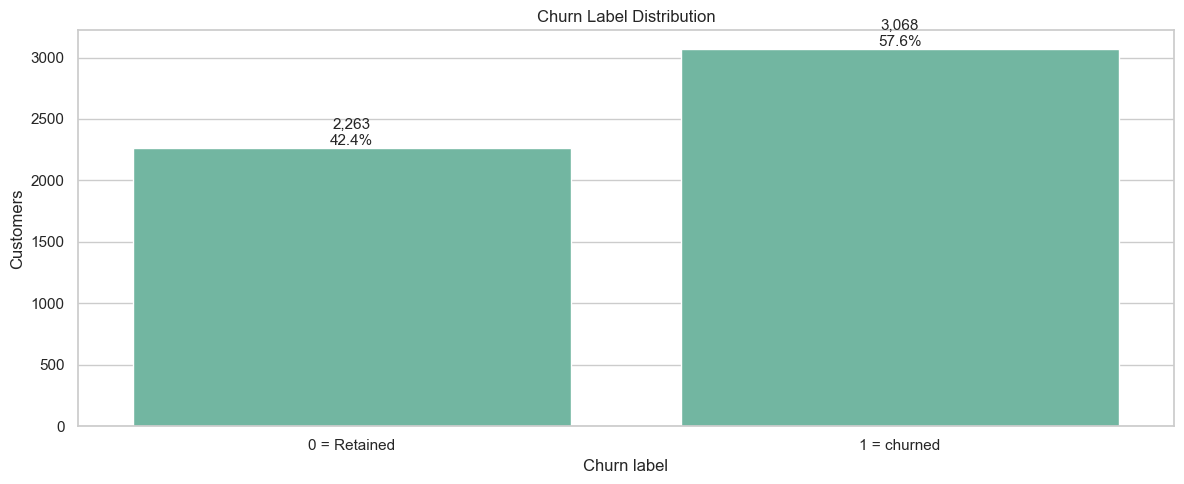

In [2]:
observation_customers = (
    df.loc[
        (df["invoice_date"] <= OBSERVATION_END)
        & df["customer_id"].notna()
        & (df["customer_id"].str.strip() != ""),  # [FIX] Remove anonymous aggregation rows
        "customer_id",
    ]
    .drop_duplicates()
    .sort_values()
)

evaluation_purchases = df.loc[
    (df["invoice_date"] > OBSERVATION_END)
    & (~df["is_cancellation"])
    & df["customer_id"].notna()
    & (df["customer_id"].str.strip() != ""),  # [FIX] Consistent filter
    "customer_id",
].drop_duplicates()

labels = pd.DataFrame({"customer_id": observation_customers})
labels["churn"] = (~labels["customer_id"].isin(evaluation_purchases)).astype(int)

class_summary = (
    labels["churn"]
    .value_counts(normalize=False)
    .rename_axis("churn")
    .reset_index(name="customers")
)
class_summary["pct"] = class_summary["customers"] / class_summary["customers"].sum()

churn_rate = labels["churn"].mean()
print(class_summary)
print(f"Expected churn rate: 60%-70%")
print(f"Actual churn rate: {churn_rate:.2%}")
if 0.60 <= churn_rate <= 0.70:
    print("Churn rate is inside the expected range.")
else:
    print("Review label window or data freshness: churn rate is outside the expected range.")

plt.figure(figsize=(12, 5))
ax = sns.countplot(data=labels, x="churn", order=[0, 1])
ax.set_title("Churn Label Distribution")
ax.set_xlabel("Churn label")
ax.set_ylabel("Customers")
ax.set_xticklabels(["0 = Retained", "1 = churned"])

for patch in ax.patches:
    count = int(patch.get_height())
    pct = count / len(labels)
    ax.annotate(
        f"{count:,}\n{pct:.1%}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
    )

plt.tight_layout()
plt.show()


## 2. Feature Engineering (Observation Period Only)

All features are computed from transactions on or before `OBSERVATION_END`. The evaluation period is used only for labels, preventing temporal leakage.

In [24]:
# FEATURE COLUMNS
# [UPDATED] Added 8 new engineered features; removed frequency_last_180d (redundant)
FEATURE_COLUMNS = [
    # RFM Core
    "recency_days",
    "frequency",
    "monetary",
    # Time-windowed
    "frequency_last_30d",
    "frequency_last_90d",
    "monetary_last_90d",
    # Behavioral
    "avg_order_value",
    "avg_basket_size",
    "avg_unit_price",
    "total_quantity",
    "unique_products",
    # Temporal
    "tenure_days",
    "avg_days_between_orders",
    "std_days_between_orders",
    "days_since_first_purchase",
    "is_one_time_buyer",
    # Engagement
    "cancellation_rate",
    "return_quantity_rate",
    "weekend_purchase_ratio",
    # Monetary pattern
    "monetary_trend",
    "max_single_order_value",
    "min_single_order_value",
    "ratio_frequency_90d",
    # ✨ NEW — Velocity / Trend Ratios
    "velocity_ratio_180d",       # % purchases in last 180d vs all-time
    "spending_recency_ratio",    # % spending in last 90d vs all-time
    "velocity_ratio_30d_90d",    # short-term acceleration (30d vs 90d)
    # ✨ NEW — Behavioural Signals
    "overdue_ratio",             # recency / avg gap — is customer overdue?
    "purchase_regularity",       # CoV of inter-purchase gaps (low = regular)
    "recency_one_time",          # recency × is_one_time_buyer interaction
    "product_diversity_trend",   # unique products last 90d / all-time
    "monetary_acceleration",     # second-half spending / first-half spending
    # Categorical
    "is_uk",
]


def safe_divide(numerator, denominator, default=0.0):
    result = numerator / denominator.replace(0, np.nan)
    return result.replace([np.inf, -np.inf], np.nan).fillna(default)


def monthly_slope(customer_monthly: pd.DataFrame) -> float:
    if len(customer_monthly) < 2:
        return 0.0
    x = customer_monthly["month_index"].to_numpy(dtype=float)
    y = customer_monthly["line_amount"].to_numpy(dtype=float)
    x = x - x.min()
    if np.allclose(y, y[0]):
        return 0.0
    return float(linregress(x, y).slope)


def build_customer_features(transactions: pd.DataFrame, observation_end: pd.Timestamp) -> pd.DataFrame:
    # Filter to observation period, remove anonymous rows
    obs = transactions.loc[
        (transactions["invoice_date"] <= observation_end)
        & transactions["customer_id"].notna()
        & (transactions["customer_id"].str.strip() != "")  # [FIX P1.1] drop anonymous
    ].copy()
    valid = obs.loc[~obs["is_cancellation"]].copy()

    if obs.empty or valid.empty:
        raise ValueError("Observation period does not contain enough customer transactions.")

    valid["price_quantity"] = valid["price"] * valid["quantity"]

    # Core RFM aggregation
    rfm = valid.groupby("customer_id").agg(
        last_purchase_date=("invoice_date", "max"),
        first_purchase_date=("invoice_date", "min"),
        frequency=("invoice", "nunique"),
        monetary=("line_amount", "sum"),
        total_quantity=("quantity", "sum"),
        unique_products=("stock_code", "nunique"),
        price_quantity_sum=("price_quantity", "sum"),
    )
    rfm["recency_days"] = (observation_end - rfm["last_purchase_date"]).dt.days
    rfm["tenure_days"] = (rfm["last_purchase_date"] - rfm["first_purchase_date"]).dt.days
    rfm["days_since_first_purchase"] = (observation_end - rfm["first_purchase_date"]).dt.days
    rfm["avg_order_value"] = safe_divide(rfm["monetary"], rfm["frequency"])
    rfm["avg_basket_size"] = safe_divide(rfm["total_quantity"], rfm["frequency"])
    rfm["avg_unit_price"] = safe_divide(rfm["price_quantity_sum"], rfm["total_quantity"])
    rfm["is_one_time_buyer"] = (rfm["frequency"] == 1).astype(int)

    # Inter-purchase gap features
    invoice_dates = (
        valid.groupby(["customer_id", "invoice"], as_index=False)
        .agg(invoice_date=("invoice_date", "min"))
        .sort_values(["customer_id", "invoice_date"])
    )
    invoice_dates["gap_days"] = (
        invoice_dates.groupby("customer_id")["invoice_date"].diff().dt.total_seconds() / 86_400
    )
    gap_features = invoice_dates.groupby("customer_id")["gap_days"].agg(
        avg_days_between_orders="mean",
        std_days_between_orders="std",
    )

    invoice_dates["is_weekend"] = invoice_dates["invoice_date"].dt.dayofweek.isin([5, 6]).astype(int)
    weekend_ratio = invoice_dates.groupby("customer_id")["is_weekend"].mean().rename("weekend_purchase_ratio")

    # Cancellation / return features
    invoice_counts = obs.groupby("customer_id")["invoice"].nunique().rename("invoice_count")
    cancellation_invoices = (
        obs.loc[obs["is_cancellation"]].groupby("customer_id")["invoice"].nunique().rename("cancellation_invoice_count")
    )
    cancellation_rate = safe_divide(
        cancellation_invoices.reindex(invoice_counts.index).fillna(0), invoice_counts
    ).rename("cancellation_rate")

    qty_positive = obs.loc[obs["quantity"] > 0].groupby("customer_id")["quantity"].sum().rename("qty_positive")
    qty_negative = obs.loc[obs["quantity"] < 0].groupby("customer_id")["quantity"].sum().abs().rename("qty_returned")
    return_quantity_rate = safe_divide(
        qty_negative.reindex(invoice_counts.index).fillna(0),
        qty_positive.reindex(invoice_counts.index).fillna(0),
    ).rename("return_quantity_rate")

    # Per-invoice value features
    invoice_values = valid.groupby(["customer_id", "invoice"], as_index=False).agg(
        invoice_value=("line_amount", "sum")
    )
    order_value_features = invoice_values.groupby("customer_id")["invoice_value"].agg(
        max_single_order_value="max",
        min_single_order_value="min",
    )

    # Monetary trend (linear slope on monthly revenue)
    monthly = valid.assign(
        month_index=valid["invoice_date"].dt.year * 12 + valid["invoice_date"].dt.month
    )
    monthly = monthly.groupby(["customer_id", "month_index"], as_index=False)["line_amount"].sum()
    monetary_trend = monthly.groupby("customer_id").apply(monthly_slope).rename("monetary_trend")

    # Time-windowed features (30d / 90d / 180d)
    obs_30d = obs.loc[obs["invoice_date"] >= observation_end - pd.Timedelta(days=30)]
    valid_30d = obs_30d.loc[~obs_30d["is_cancellation"]]
    freq_30d = valid_30d.groupby("customer_id")["invoice"].nunique().rename("frequency_last_30d")

    obs_90d = obs.loc[obs["invoice_date"] >= observation_end - pd.Timedelta(days=90)]
    valid_90d = obs_90d.loc[~obs_90d["is_cancellation"]]
    freq_90d = valid_90d.groupby("customer_id")["invoice"].nunique().rename("frequency_last_90d")
    monetary_90d = valid_90d.groupby("customer_id")["line_amount"].sum().rename("monetary_last_90d")

    obs_180d = obs.loc[obs["invoice_date"] >= observation_end - pd.Timedelta(days=180)]
    valid_180d = obs_180d.loc[~obs_180d["is_cancellation"]]
    freq_180d = valid_180d.groupby("customer_id")["invoice"].nunique().rename("frequency_last_180d")

    # [NEW P2.5] Product diversity in last 90d
    unique_products_90d = (
        valid_90d.groupby("customer_id")["stock_code"].nunique().rename("unique_products_90d")
    )

    # [NEW P2.6] Monetary acceleration (2nd-half vs 1st-half spending)
    obs_min_date = valid["invoice_date"].min()
    mid_point = obs_min_date + (observation_end - obs_min_date) / 2
    monetary_first_half = (
        valid.loc[valid["invoice_date"] < mid_point]
        .groupby("customer_id")["line_amount"]
        .sum()
        .rename("monetary_first_half")
    )
    monetary_second_half = (
        valid.loc[valid["invoice_date"] >= mid_point]
        .groupby("customer_id")["line_amount"]
        .sum()
        .rename("monetary_second_half")
    )

    is_uk = obs.groupby("customer_id")["country"].first().apply(lambda x: 1 if x == "United Kingdom" else 0).rename("is_uk")

    # Assemble base feature matrix
    features = (
        rfm.join(gap_features)
        .join(cancellation_rate)
        .join(return_quantity_rate)
        .join(weekend_ratio)
        .join(order_value_features)
        .join(monetary_trend)
        .join(freq_30d)
        .join(freq_90d)
        .join(monetary_90d)
        .join(freq_180d)
        .join(unique_products_90d)
        .join(monetary_first_half)
        .join(monetary_second_half)
        .join(is_uk)
        .reset_index()
    )

    # Fill missing windowed features (customers absent in a window = 0)
    features["frequency_last_30d"] = features["frequency_last_30d"].fillna(0)
    features["frequency_last_90d"] = features["frequency_last_90d"].fillna(0)
    features["monetary_last_90d"] = features["monetary_last_90d"].fillna(0)
    features["frequency_last_180d"] = features["frequency_last_180d"].fillna(0)
    features["unique_products_90d"] = features["unique_products_90d"].fillna(0)
    features["monetary_first_half"] = features["monetary_first_half"].fillna(0)
    features["monetary_second_half"] = features["monetary_second_half"].fillna(0)
    features["is_uk"] = features["is_uk"].fillna(0)
    features["monetary_trend"] = features["monetary_trend"].fillna(0)
    features["cancellation_rate"] = features["cancellation_rate"].fillna(0)
    features["return_quantity_rate"] = features["return_quantity_rate"].fillna(0)
    features["weekend_purchase_ratio"] = features["weekend_purchase_ratio"].fillna(0)

    # [FIX P1.3] Improved imputation for one-time buyers
    # std_days_between_orders = NaN for one-time buyers → 0 (no variability)
    features["std_days_between_orders"] = features["std_days_between_orders"].fillna(0)
    # avg_days_between_orders = NaN for one-time buyers → use recency_days as sentinel
    features["avg_days_between_orders"] = features["avg_days_between_orders"].fillna(
        features["recency_days"]
    )

    # Derived ratio features
    features["ratio_frequency_90d"] = safe_divide(features["frequency_last_90d"], features["frequency"])

    # ✨ [NEW P2.1] Velocity / trend ratios
    features["velocity_ratio_180d"] = safe_divide(features["frequency_last_180d"], features["frequency"])
    features["spending_recency_ratio"] = safe_divide(features["monetary_last_90d"], features["monetary"])
    features["velocity_ratio_30d_90d"] = safe_divide(
        features["frequency_last_30d"],
        features["frequency_last_90d"].add(1),
    )

    # ✨ [NEW P2.2] Overdue ratio — most important churn signal
    # ratio > 2 means customer is buying later than their normal gap → strong churn risk
    features["overdue_ratio"] = safe_divide(
        features["recency_days"], features["avg_days_between_orders"]
    ).clip(upper=10.0)

    # ✨ [NEW P2.3] Purchase regularity (Coefficient of Variation)
    # low CoV → purchases are regular → loyal customer
    features["purchase_regularity"] = safe_divide(
        features["std_days_between_orders"], features["avg_days_between_orders"]
    ).clip(upper=5.0)

    # ✨ [NEW P2.4] Recency × one-time buyer interaction
    features["recency_one_time"] = features["recency_days"] * features["is_one_time_buyer"]

    # ✨ [NEW P2.5] Product diversity trend (90d vs all-time)
    features["product_diversity_trend"] = safe_divide(
        features["unique_products_90d"], features["unique_products"]
    )

    # ✨ [NEW P2.6] Monetary acceleration (second-half spending / first-half + 1)
    features["monetary_acceleration"] = safe_divide(
        features["monetary_second_half"],
        features["monetary_first_half"].add(1),
    ).clip(upper=20.0)

    return features[["customer_id", *FEATURE_COLUMNS]]


features = build_customer_features(df, OBSERVATION_END)
model_df = features.merge(labels, on="customer_id", how="inner")

print(f"Feature matrix shape: {features.shape}")
print(f"Modeling dataset shape: {model_df.shape}")
print(f"Feature count: {len(FEATURE_COLUMNS)}")
model_df.head(10)


Feature matrix shape: (5268, 33)
Modeling dataset shape: (5268, 34)
Feature count: 32


,customer_id,recency_days,frequency,monetary,frequency_last_30d,frequency_last_90d,monetary_last_90d,avg_order_value,avg_basket_size,avg_unit_price,total_quantity,unique_products,tenure_days,avg_days_between_orders,std_days_between_orders,days_since_first_purchase,is_one_time_buyer,cancellation_rate,return_quantity_rate,weekend_purchase_ratio,monetary_trend,max_single_order_value,min_single_order_value,ratio_frequency_90d,velocity_ratio_180d,spending_recency_ratio,velocity_ratio_30d_90d,overdue_ratio,purchase_regularity,recency_one_time,product_diversity_trend,monetary_acceleration,is_uk,churn
0,12346,230,12,"77,556.4600",0.0000,0.0000,0.0000,"6,463.0383","6,190.4167",1.0440,"74,285.0000",27,400,36.3691,65.5145,630,0,0.2941,0.9993,0.6667,"5,930.8800","77,183.6000",1.0000,0.0000,0.0000,0.0000,0.0000,6.3240,1.8014,0,0.0000,20.0000,1,1
1,12347,34,6,"3,402.3900",0.0000,2.0000,967.4300,567.0650,349.8333,1.6210,"2,099.0000",107,274,54.9539,12.9050,308,0,0.0000,0.0000,0.3333,-12.8736,711.7900,382.5200,0.3333,0.5000,0.2843,0.0000,0.6187,0.2348,0,0.3178,20.0000,0,0
2,12348,153,4,"1,709.4000",0.0000,0.0000,0.0000,427.3500,624.2500,0.6846,"2,497.0000",25,189,63.2750,21.0841,342,0,0.0000,0.0000,0.7500,6.9704,892.8000,222.1600,0.0000,0.2500,0.0000,0.0000,2.4180,0.3332,0,0.0000,6.6645,0,0
3,12349,312,3,"2,671.1400",0.0000,0.0000,0.0000,890.3800,331.0000,2.6900,993.0000,90,181,90.8969,101.8769,493,0,0.2500,0.0050,0.3333,115.3094,"1,402.6200",200.0000,0.0000,0.0000,0.0000,0.0000,3.4325,1.1208,0,0.0000,1.1048,0,0
4,12350,214,1,334.4000,0.0000,0.0000,0.0000,334.4000,197.0000,1.6975,197.0000,17,0,214.0000,0.0000,214,1,0.0000,0.0000,0.0000,0.0000,334.4000,334.4000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,214,0.0000,20.0000,0,1
5,12351,279,1,300.9300,0.0000,0.0000,0.0000,300.9300,261.0000,1.1530,261.0000,21,0,279.0000,0.0000,279,1,0.0000,0.0000,1.0000,0.0000,300.9300,300.9300,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,279,0.0000,20.0000,0,1
6,12352,166,7,"1,905.6100",0.0000,0.0000,0.0000,272.2300,63.1429,4.3113,442.0000,38,130,21.7069,28.8840,297,0,0.3000,0.1493,0.5714,59.9615,840.3000,120.3300,0.0000,0.2857,0.0000,0.0000,7.6473,1.3306,0,0.0000,20.0000,0,0
7,12353,108,2,406.7600,0.0000,0.0000,0.0000,203.3800,106.0000,1.9187,212.0000,23,204,204.2104,0.0000,313,0,0.0000,0.0000,0.0000,-32.6800,317.7600,89.0000,0.0000,0.5000,0.0000,0.0000,0.5289,0.0000,0,0.0000,20.0000,0,1
8,12354,137,1,"1,079.4000",0.0000,0.0000,0.0000,"1,079.4000",530.0000,2.0366,530.0000,58,0,137.0000,0.0000,137,1,0.0000,0.0000,0.0000,0.0000,"1,079.4000","1,079.4000",0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,137,0.0000,20.0000,0,1
9,12355,118,2,947.6100,0.0000,0.0000,0.0000,473.8050,271.5000,1.7451,543.0000,35,353,353.0764,0.0000,472,0,0.0000,0.0000,0.5000,-2.4008,488.2100,459.4000,0.0000,0.5000,0.0000,0.0000,0.3342,0.0000,0,0.0000,0.9391,0,1


## 3. Exploratory Data Analysis (EDA)

Inspect distributions, correlations, label separation, missing values, and outliers. Outliers are retained because tree models can use them and they may represent meaningful high-value customer behavior.

Missing value summary:


,message
0,No missing feature values found.


Handling strategy: median imputation inside sklearn pipelines.
Outlier note: anonymous customer_id rows removed at source; tree models handle remaining skew.


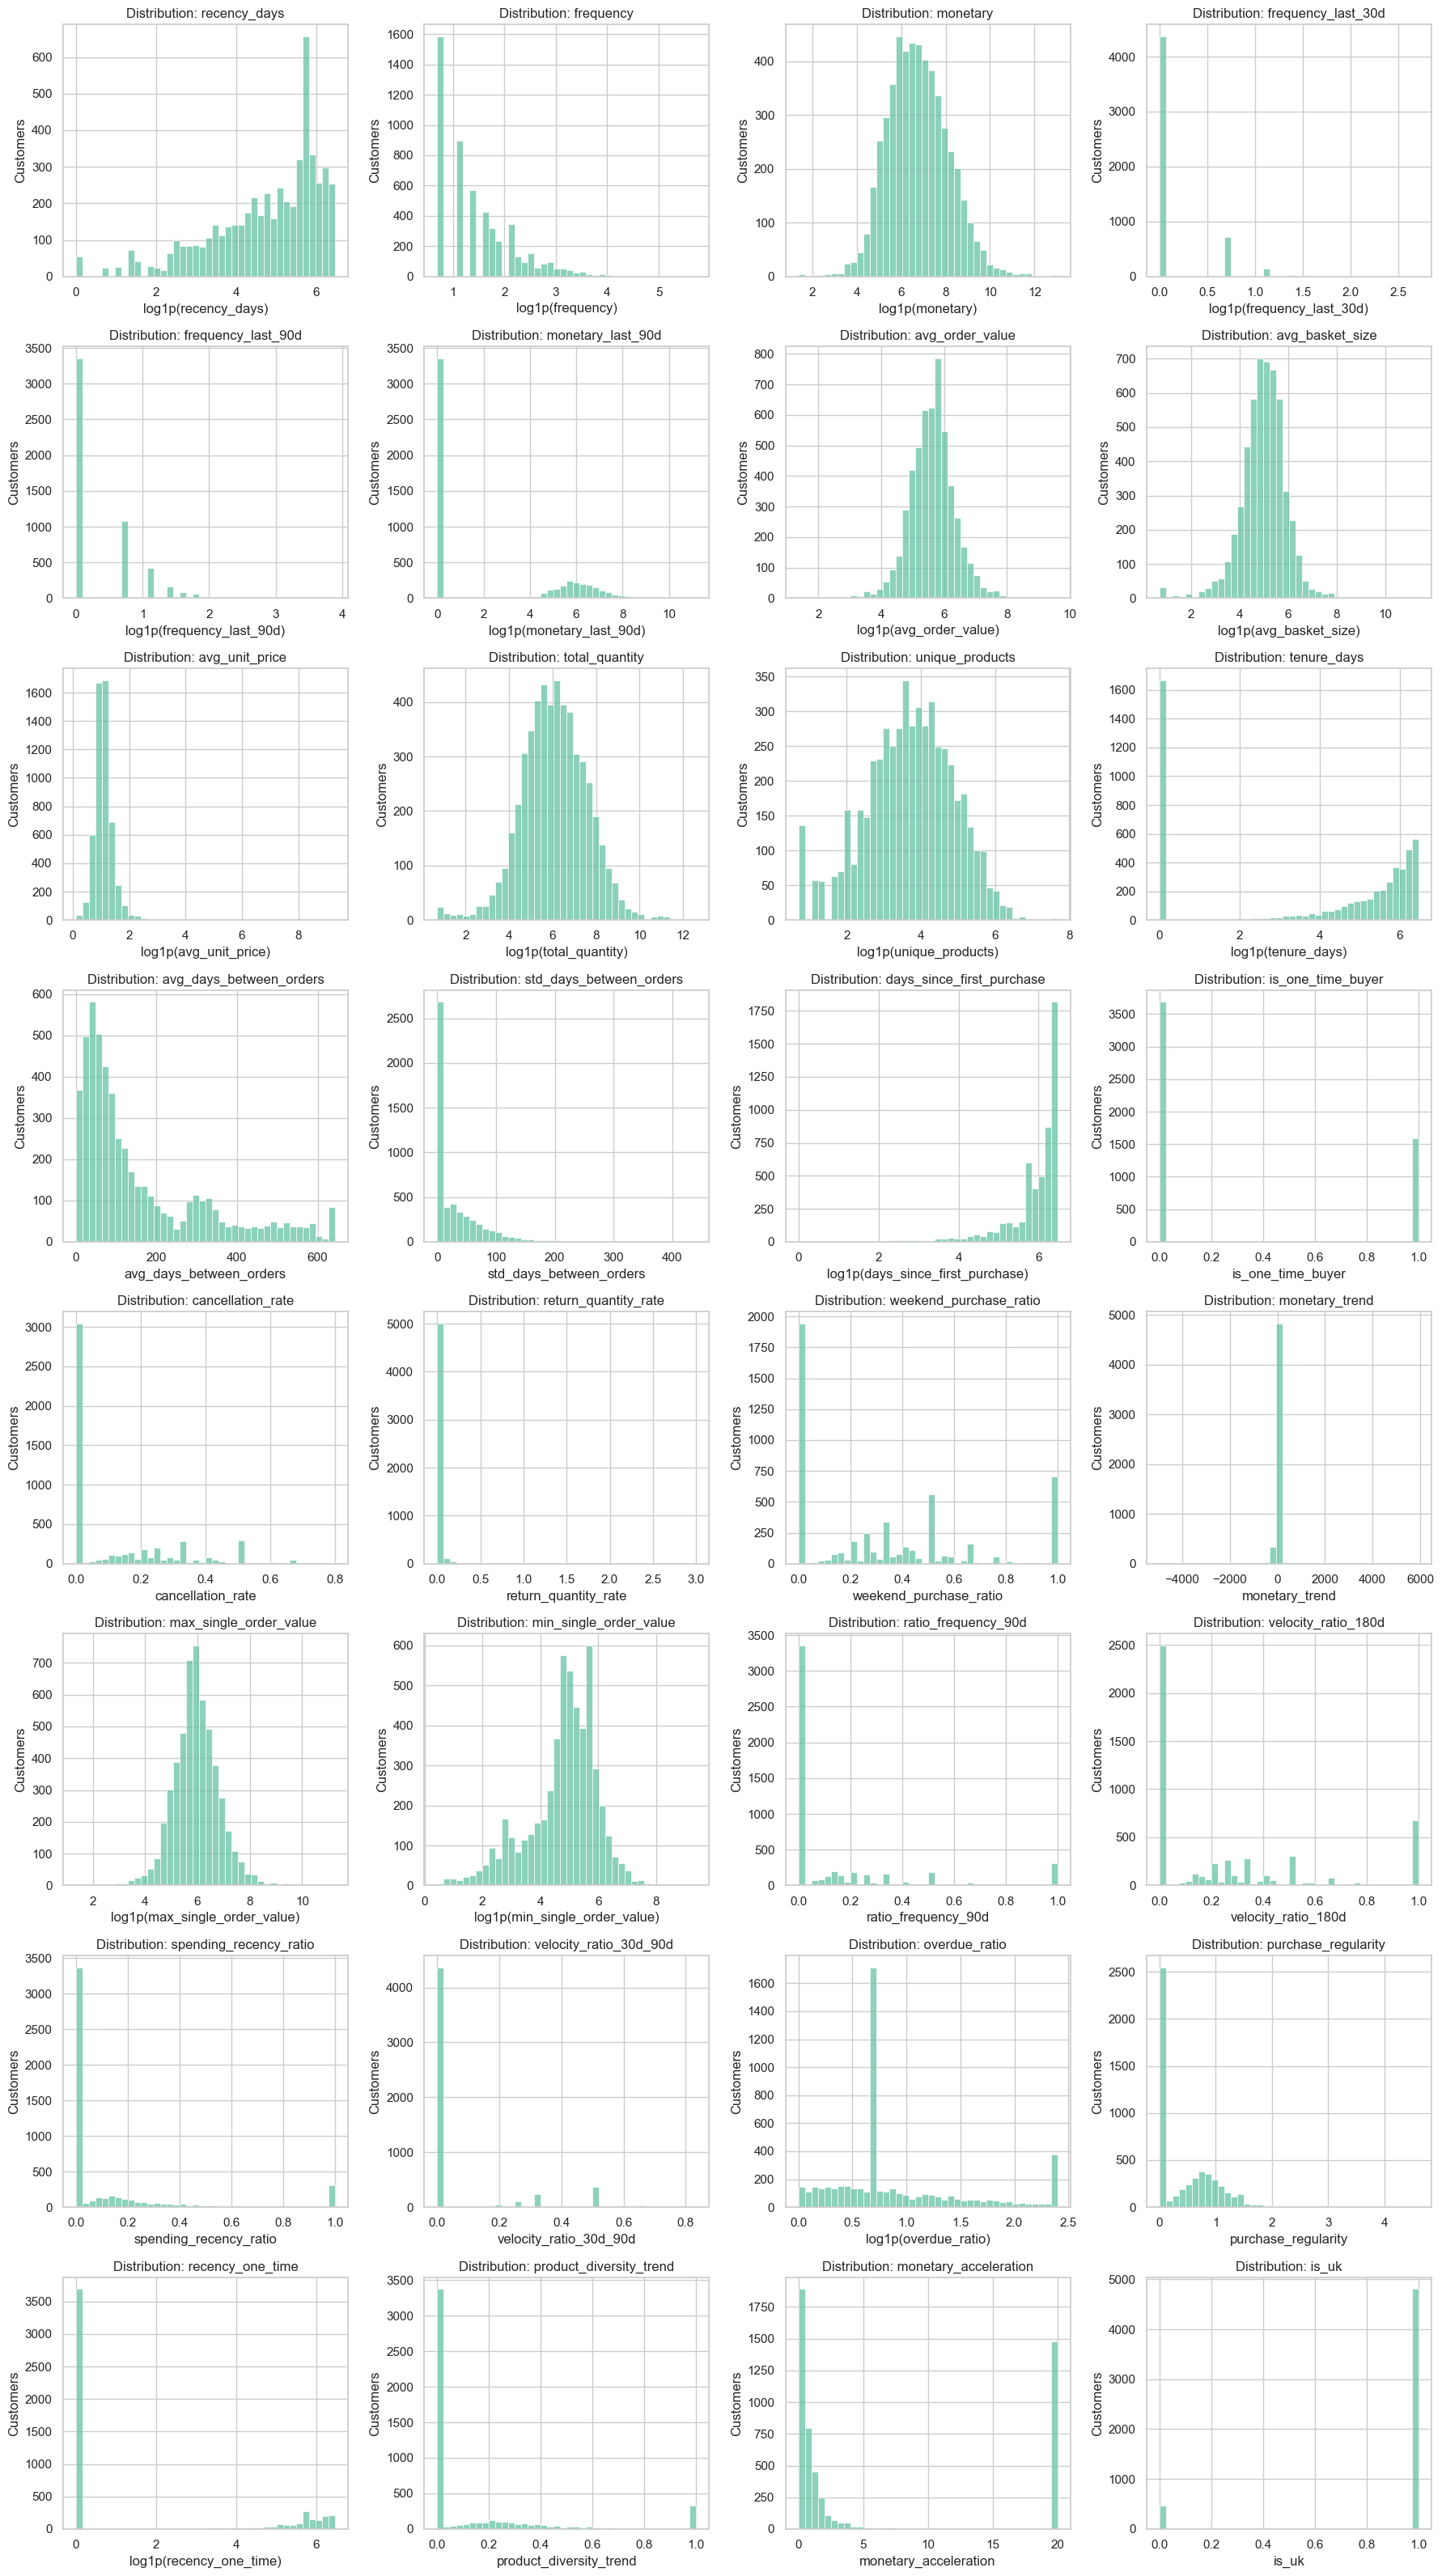

In [4]:
# DATA QUALITY CHECK
missing_summary = (
    model_df[FEATURE_COLUMNS]
    .isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: x["missing_count"] / len(model_df))
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)

print("Missing value summary:")
display(missing_summary if not missing_summary.empty else pd.DataFrame({"message": ["No missing feature values found."]}))
print("Handling strategy: median imputation inside sklearn pipelines.")
print("Outlier note: anonymous customer_id rows removed at source; tree models handle remaining skew.")

# SKEWED COLUMNS (for log1p transform in preprocessing pipeline)
# [UPDATED] Added new skewed features: overdue_ratio, recency_one_time
skewed_cols = [
    "recency_days",
    "frequency",
    "monetary",
    "avg_order_value",
    "avg_basket_size",
    "avg_unit_price",
    "total_quantity",
    "unique_products",
    "tenure_days",
    "days_since_first_purchase",
    "max_single_order_value",
    "min_single_order_value",
    "frequency_last_30d",
    "frequency_last_90d",
    "monetary_last_90d",
    "overdue_ratio",       # NEW — right-skewed (capped at 10)
    "recency_one_time",   # NEW — right-skewed (recency × binary flag)
]
skewed_cols = [c for c in skewed_cols if c in FEATURE_COLUMNS]

# DISTRIBUTION PLOTS
skewed_positive = set(skewed_cols)

n_cols = 4
n_rows = int(np.ceil(len(FEATURE_COLUMNS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(FEATURE_COLUMNS):
    series = model_df[feature].replace([np.inf, -np.inf], np.nan).dropna()
    if feature in skewed_positive:
        plot_values = np.log1p(series.clip(lower=0))
        xlabel = f"log1p({feature})"
    else:
        plot_values = series
        xlabel = feature
    sns.histplot(plot_values, bins=40, kde=False, ax=axes[idx])
    axes[idx].set_title(f"Distribution: {feature}")
    axes[idx].set_xlabel(xlabel)
    axes[idx].set_ylabel("Customers")

for ax in axes[len(FEATURE_COLUMNS):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


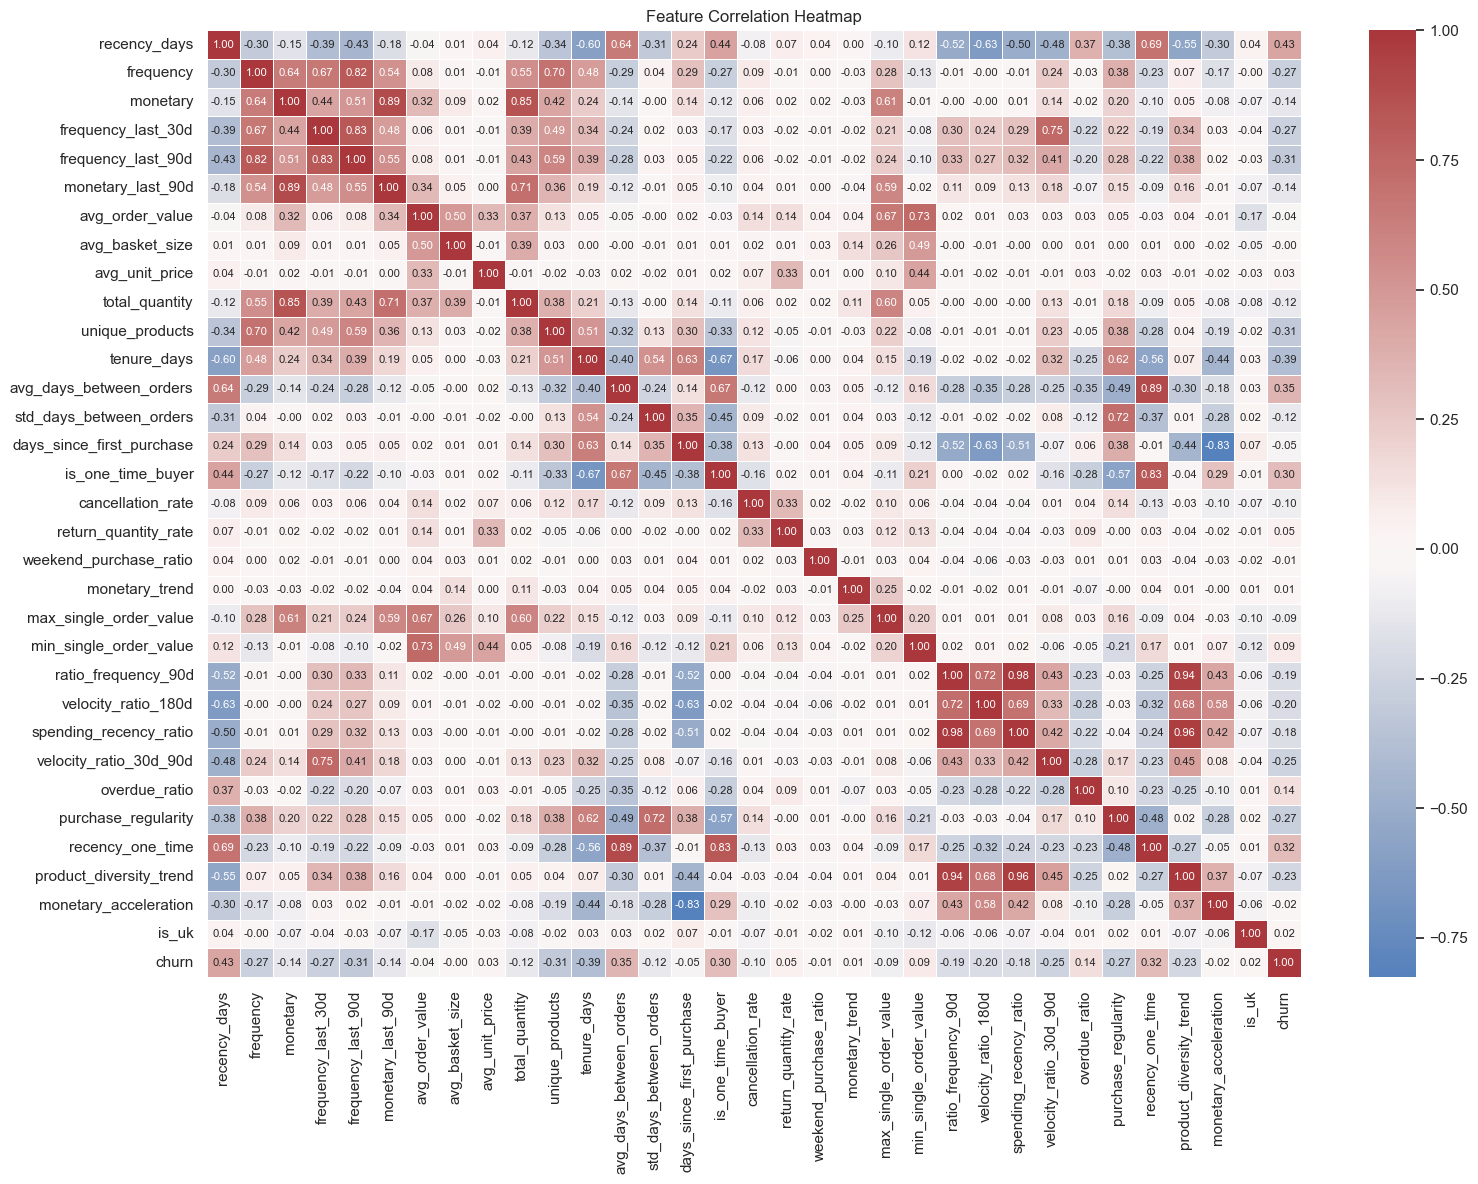

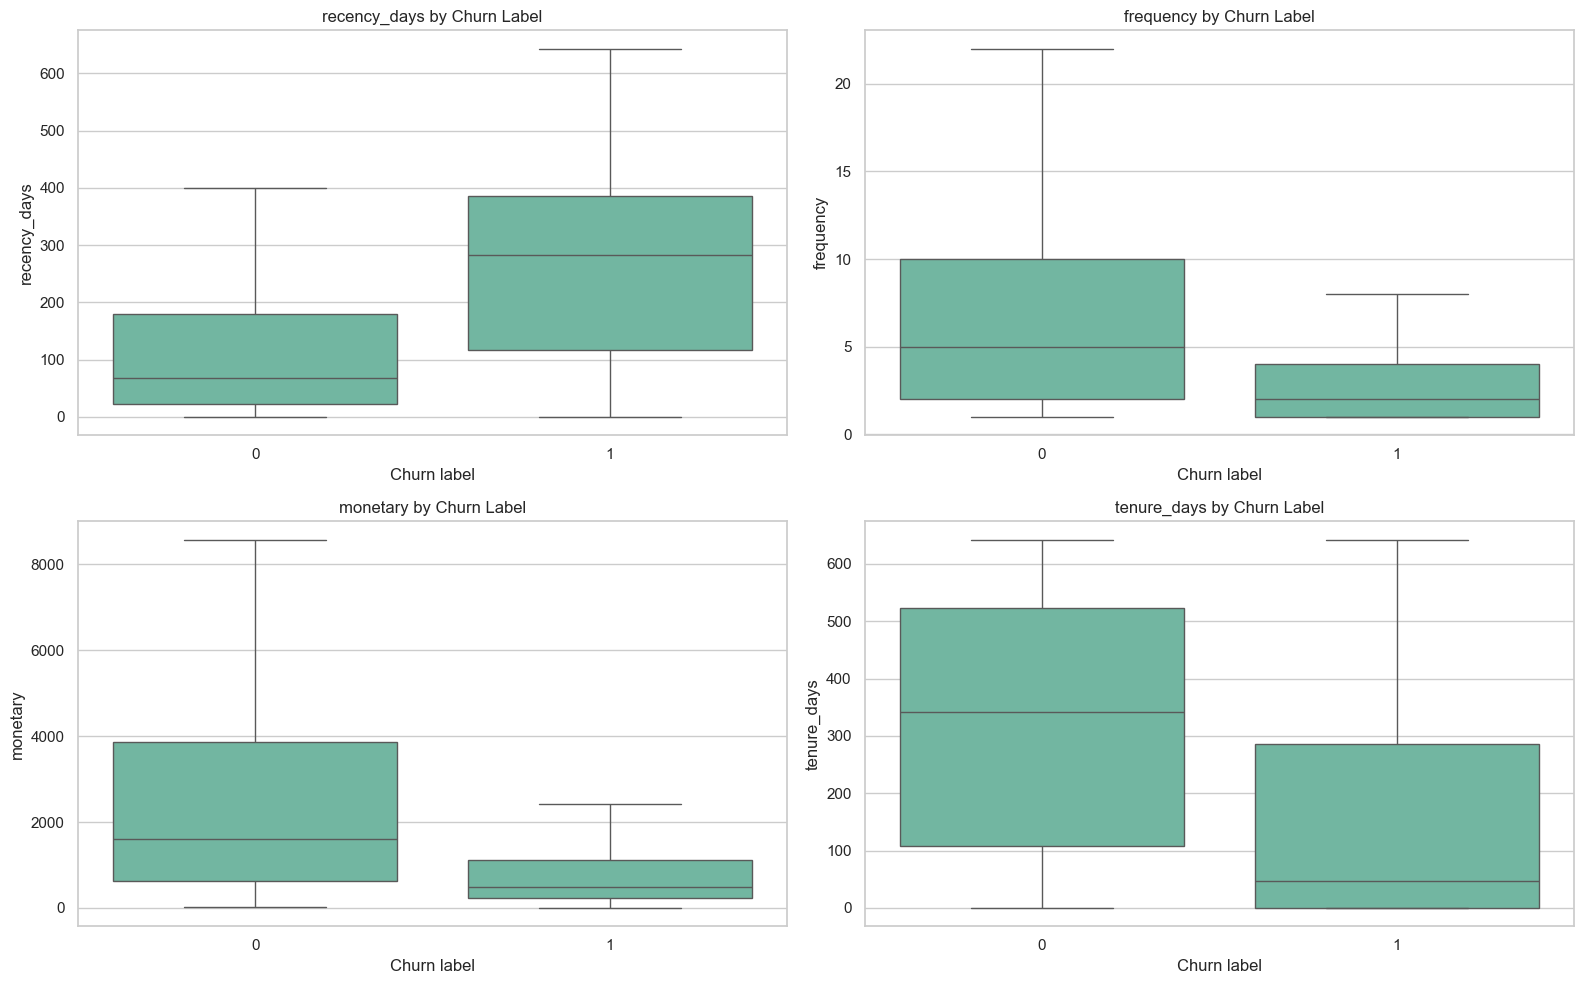

In [5]:
plt.figure(figsize=(16, 12))
corr = model_df[FEATURE_COLUMNS + ["churn"]].corr(numeric_only=True)
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.5, square=False, annot=True, fmt=".2f", annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

key_features = ["recency_days", "frequency", "monetary", "tenure_days"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, feature in zip(axes, key_features):
    sns.boxplot(data=model_df, x="churn", y=feature, ax=ax, showfliers=False)
    ax.set_title(f"{feature} by Churn Label")
    ax.set_xlabel("Churn label")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## 4. Preprocessing & Train/Test Split

Create a stratified 80/20 split and define separate preprocessing pipelines: scaled features for Logistic Regression, median-imputed raw numeric features for tree models.

In [14]:
X = model_df[FEATURE_COLUMNS].copy()
y = model_df["churn"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train class distribution:")
display(y_train.value_counts(normalize=True).rename("train_pct").to_frame())
print("Test class distribution:")
display(y_test.value_counts(normalize=True).rename("test_pct").to_frame())

scaled_numeric_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

numeric_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

Train class distribution:


,train_pct
churn,
1,0.5707
0,0.4293


Test class distribution:


,test_pct
churn,
1,0.5712
0,0.4288


### LazyPredict

Sử dụng LazyPredict để tạo baseline model và so sánh nhanh các thuật toán classification.

In [15]:
# Import thư viện cần thiết
from lazypredict.Supervised import LazyClassifier
from sklearn.metrics import recall_score

# Tạo hàm tính Recall dành riêng cho class 1 (Churn)
def recall_churn(y_true, y_pred):
    return recall_score(y_true, y_pred, pos_label=1)


from sklearn.preprocessing import FunctionTransformer, StandardScaler
import numpy as np

skewed_cols = [
    "recency_days", "frequency", "monetary", "avg_order_value", "avg_basket_size", 
    "avg_unit_price", "total_quantity", "unique_products", "tenure_days", 
    "days_since_first_purchase", "max_single_order_value", "min_single_order_value",
    "frequency_last_30d", "frequency_last_90d", "monetary_last_90d", "frequency_last_180d"
]
skewed_cols = [c for c in skewed_cols if c in X_train.columns]

X_train_log = X_train.copy()
X_test_log = X_test.copy()

for c in skewed_cols:
    X_train_log[c] = np.log1p(np.clip(X_train_log[c], 0, None))
    X_test_log[c] = np.log1p(np.clip(X_test_log[c], 0, None))

# Khởi tạo mô hình LazyClassifier với custom_metric
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=recall_churn)

# Fit mô hình để tự động train và đánh giá hàng chục algorithms
models, predictions = clf.fit(X_train_log, X_test_log, y_train, y_test)

# Hiển thị bảng kết quả
display(models)


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,recall_churn,Time Taken
Model,,,,,,,,
LinearDiscriminantAnalysis,0.7533,0.7413,0.8117,0.7510,0.7522,0.7533,0.8256,0.0372
RidgeClassifierCV,0.7533,0.7413,0.8114,0.7510,0.7522,0.7533,0.8256,0.0271
RidgeClassifier,0.7495,0.7369,0.8108,0.7469,0.7484,0.7495,0.8256,0.0281
LinearSVC,0.7457,0.7330,0.8119,0.7431,0.7445,0.7457,0.8223,0.0573
CalibratedClassifierCV,0.7448,0.7325,0.8122,0.7423,0.7435,0.7448,0.8189,0.2001
LogisticRegression,0.7429,0.7292,0.8112,0.7398,0.7418,0.7429,0.8256,0.0439
SGDClassifier,0.7353,0.7289,0.8025,0.7350,0.7348,0.7353,0.7741,0.0416
NearestCentroid,0.7249,0.7266,0.7849,0.7262,0.7312,0.7249,0.7143,0.0264
SVC,0.7410,0.7261,0.7985,0.7373,0.7402,0.7410,0.8306,0.6014


## 5. Model Training

Train Logistic Regression, Random Forest, and XGBoost with cross-validated hyperparameter search. Each model is wrapped in a sklearn pipeline so preprocessing stays attached to the estimator.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
trained_models = {}
training_results = []


def fit_search(name: str, search) -> None:
    start = time.perf_counter()
    search.fit(X_train, y_train)
    elapsed = time.perf_counter() - start

    trained_models[name] = search.best_estimator_
    training_results.append(
        {
            "Model": name,
            "Best CV AUC": search.best_score_,
            "Training Time (sec)": elapsed,
            "Best Params": search.best_params_,
        }
    )

    print(f"{name}")
    print(f"Best params: {search.best_params_}")
    print(f"Best CV AUC: {search.best_score_:.4f}")
    print(f"Training time: {elapsed:.1f} sec")
    print("-" * 80)


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log1p, validate=False)

skewed_numeric_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", log_transformer),
        ("scaler", StandardScaler()),
    ]
)

regular_cols = [c for c in FEATURE_COLUMNS if c not in skewed_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("skewed", skewed_numeric_preprocess, skewed_cols),
        ("regular", scaled_numeric_preprocess, regular_cols),
    ]
)

logistic_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid={"model__C": [0.01, 0.1, 1, 10], "model__penalty": ["l2"]},
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
fit_search("Logistic Regression", logistic_search)

rf_pipeline = Pipeline(
    steps=[
        ("preprocess", numeric_preprocess),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
    ]
)

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions={
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [5, 10, 15, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"],
    },
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
fit_search("Random Forest", rf_search)

if XGBClassifier is None:
    print("xgboost is not installed; skipping XGBoost training.")
else:
    class_counts = y_train.value_counts().sort_index()
    scale_pos_weight = class_counts.loc[0] / class_counts.loc[1]

    X_xgb_train, X_xgb_valid, y_xgb_train, y_xgb_valid = train_test_split(
        X_train,
        y_train,
        test_size=0.2,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )

    xgb_preprocess = SimpleImputer(strategy="median")
    X_xgb_train_processed = xgb_preprocess.fit_transform(X_xgb_train)
    X_xgb_valid_processed = xgb_preprocess.transform(X_xgb_valid)

    xgb_estimator = XGBClassifier(
        eval_metric=["logloss", "auc"],
        early_stopping_rounds=20,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    xgb_search = RandomizedSearchCV(
        estimator=xgb_estimator,
        param_distributions={
            "max_depth": [3, 5, 7],
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "gamma": [0, 0.1, 0.5],
            "min_child_weight": [1, 3, 5],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0],
        },
        n_iter=50,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
    )

    start = time.perf_counter()
    xgb_search.fit(
        X_xgb_train_processed,
        y_xgb_train,
        eval_set=[(X_xgb_valid_processed, y_xgb_valid)],
        verbose=False,
    )
    elapsed = time.perf_counter() - start

    xgb_pipeline = Pipeline(
        steps=[
            ("preprocess", xgb_preprocess),
            ("model", xgb_search.best_estimator_),
        ]
    )

    trained_models["XGBoost"] = xgb_pipeline
    training_results.append(
        {
            "Model": "XGBoost",
            "Best CV AUC": xgb_search.best_score_,
            "Training Time (sec)": elapsed,
            "Best Params": xgb_search.best_params_,
        }
    )

    print("XGBoost")
    print(f"scale_pos_weight: {scale_pos_weight:.4f}")
    print(f"Best params: {xgb_search.best_params_}")
    print(f"Best CV AUC: {xgb_search.best_score_:.4f}")
    print(f"Training time: {elapsed:.1f} sec")

training_results_df = pd.DataFrame(training_results)
display(training_results_df)

Logistic Regression
Best params: {'model__C': 0.1, 'model__penalty': 'l2'}
Best CV AUC: 0.7977
Training time: 5.1 sec
--------------------------------------------------------------------------------
Random Forest
Best params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 5}
Best CV AUC: 0.8007
Training time: 22.5 sec
--------------------------------------------------------------------------------
XGBoost
scale_pos_weight: 0.7522
Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV AUC: 0.8061
Training time: 5.1 sec


,Model,Best CV AUC,Training Time (sec),Best Params
0,Logistic Regression,0.7977,5.0837,"{'model__C': 0.1, 'model__penalty': 'l2'}"
1,Random Forest,0.8007,22.4996,"{'model__n_estimators': 100, 'model__min_sampl..."
2,XGBoost,0.8061,5.0665,"{'subsample': 0.7, 'n_estimators': 300, 'min_c..."


## 6. Evaluation on Test Set

Evaluate each trained model on the held-out test set with classification metrics, confusion matrices, ROC curves, and a model comparison table.


Logistic Regression
              precision    recall  f1-score   support

   Purchased       0.70      0.73      0.72       452
     Churned       0.79      0.76      0.78       602

    accuracy                           0.75      1054
   macro avg       0.75      0.75      0.75      1054
weighted avg       0.75      0.75      0.75      1054



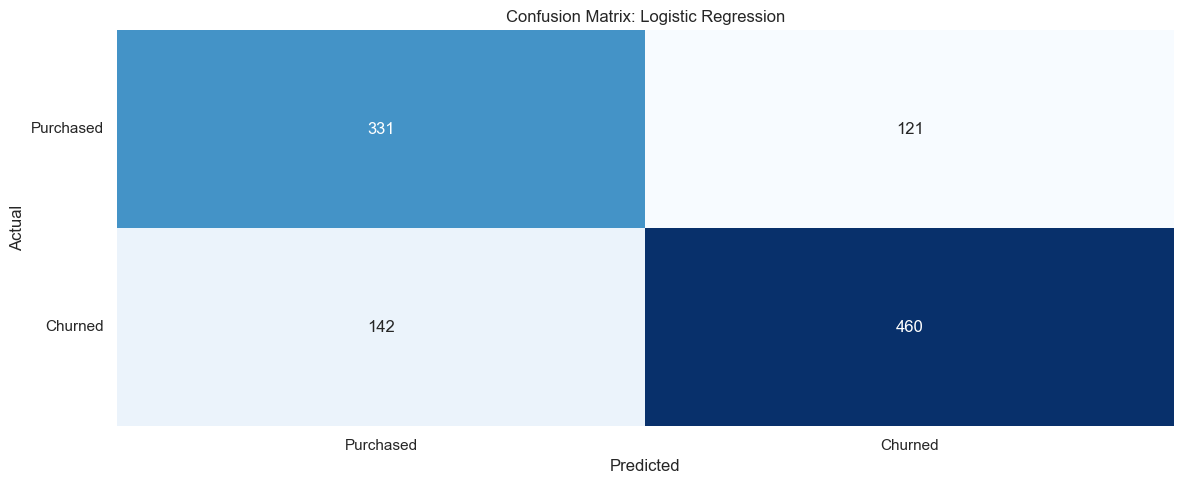


Random Forest
              precision    recall  f1-score   support

   Purchased       0.69      0.72      0.70       452
     Churned       0.78      0.76      0.77       602

    accuracy                           0.74      1054
   macro avg       0.74      0.74      0.74      1054
weighted avg       0.74      0.74      0.74      1054



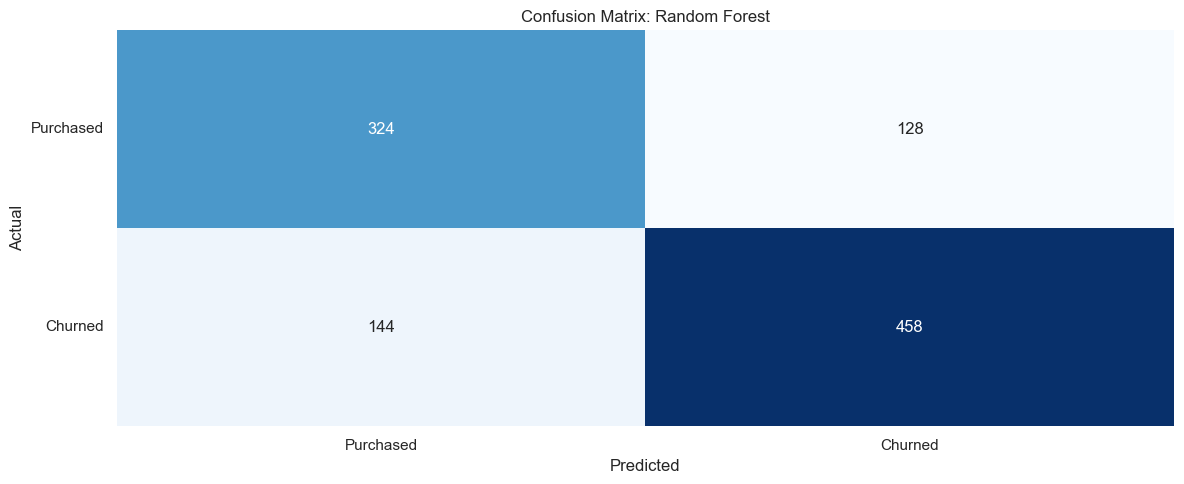


XGBoost
              precision    recall  f1-score   support

   Purchased       0.70      0.73      0.72       452
     Churned       0.79      0.77      0.78       602

    accuracy                           0.75      1054
   macro avg       0.75      0.75      0.75      1054
weighted avg       0.75      0.75      0.75      1054



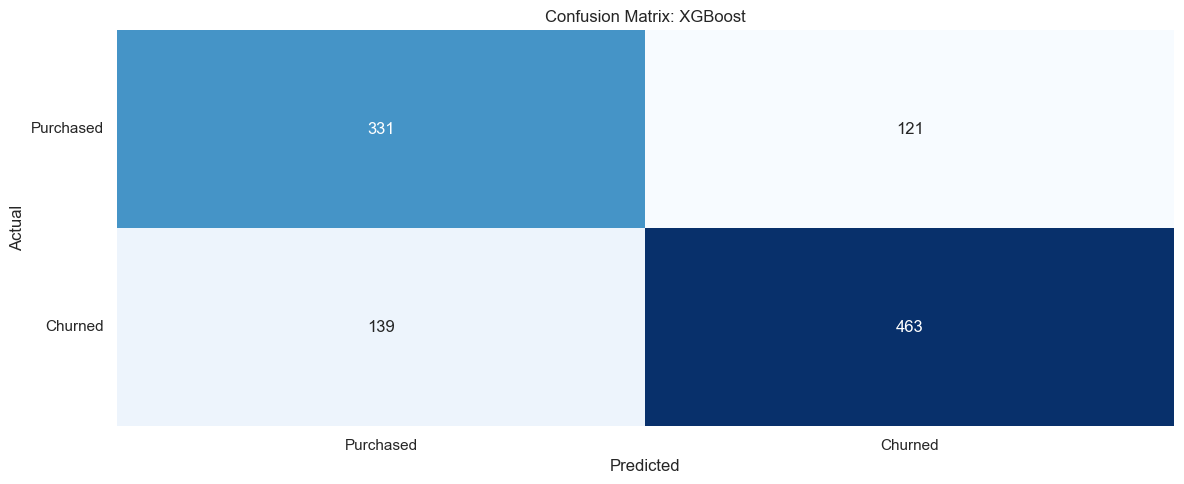

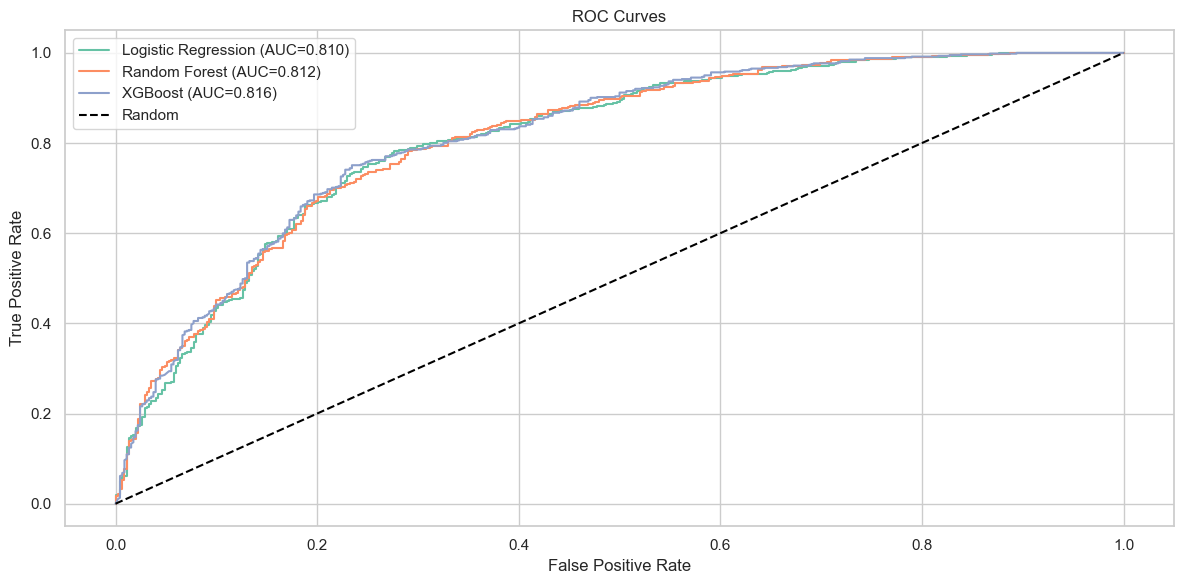

,Model,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn),AUC-ROC
0,XGBoost,0.7533,0.7928,0.7691,0.7808,0.8155
1,Random Forest,0.7419,0.7816,0.7608,0.7710,0.8118
2,Logistic Regression,0.7505,0.7917,0.7641,0.7777,0.8100


QA Gate AUC-ROC >= 0.80: PASS
Best model selected: XGBoost
From a business perspective, reducing false negatives (missed churners) is often more critical than minimizing false positives. Therefore XGBoost offers  the  most  advantageous  trade-off  for  customer  retention  strategies


In [23]:
evaluation_rows = []
roc_payload = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc_roc = roc_auc_score(y_test, y_proba)

    evaluation_rows.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (Churn)": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            "Recall (Churn)": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
            "F1 (Churn)": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
            "AUC-ROC": auc_roc,
        }
    )

    print(f"\n{name}")
    print(classification_report(y_test, y_pred, target_names=["Purchased", "Churned"], zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], ["Purchased", "Churned"])
    plt.yticks([0.5, 1.5], ["Purchased", "Churned"], rotation=0)
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_payload[name] = (fpr, tpr, auc_roc)

plt.figure(figsize=(12, 6))
for name, (fpr, tpr, auc_roc) in roc_payload.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_roc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame(evaluation_rows).sort_values("AUC-ROC", ascending=False).reset_index(drop=True)
display(comparison_df)

qa_pass = bool((comparison_df["AUC-ROC"] >= 0.80).any())
print(f"QA Gate AUC-ROC >= 0.80: {'PASS' if qa_pass else 'FAIL'}")


def select_best_model(comparison: pd.DataFrame) -> str:
    candidates = comparison.loc[comparison["AUC-ROC"] >= 0.80].copy()
    if candidates.empty:
        print("No model passed the hard AUC gate; selecting highest AUC model for diagnostics only.")
        candidates = comparison.copy()

    max_auc = candidates["AUC-ROC"].max()
    candidates = candidates.loc[candidates["AUC-ROC"] >= max_auc - 0.01].copy()
    simplicity_rank = {"Logistic Regression": 0, "Random Forest": 1, "XGBoost": 2}
    candidates["simplicity_rank"] = candidates["Model"].map(simplicity_rank).fillna(99)
    winner = candidates.sort_values(
        ["F1 (Churn)", "simplicity_rank", "AUC-ROC"],
        ascending=[False, True, False],
    ).iloc[0]
    return winner["Model"]


best_model_name = select_best_model(comparison_df)
best_model = trained_models[best_model_name]
print(f"Best model selected: {best_model_name}")
print(f"From a business perspective, reducing false negatives (missed churners) is often more critical than minimizing false positives. Therefore {best_model_name} offers  the  most  advantageous  trade-off  for  customer  retention  strategies")

## 7. Threshold Optimization (Best Model Only)

Optimize the classification threshold for the selected model by maximizing F1-score on the test set, then compare default and optimized confusion matrices.

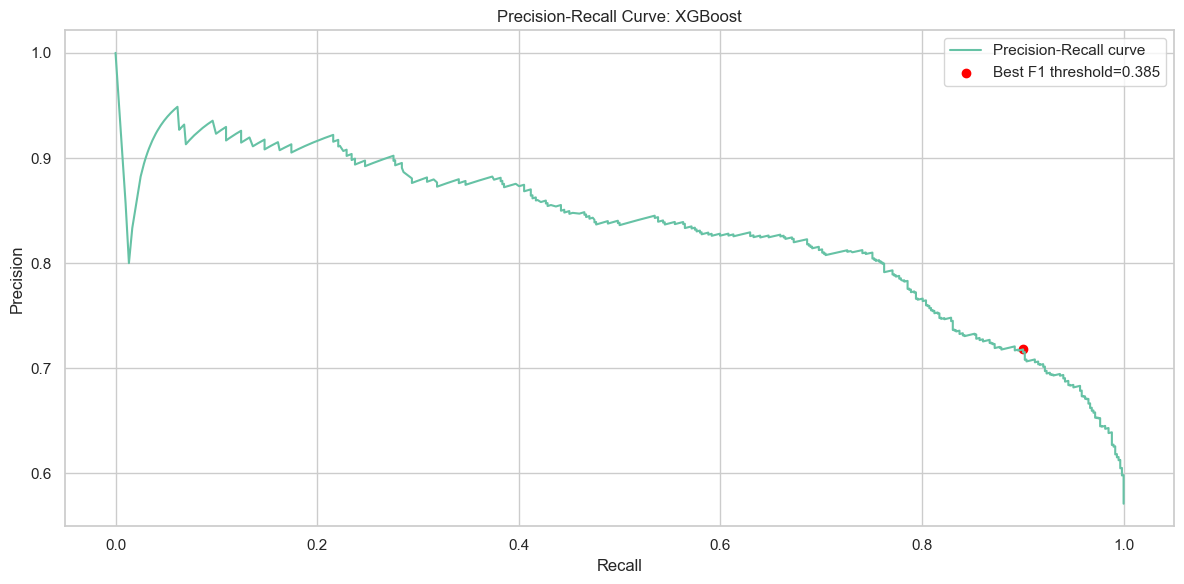

,threshold,precision_churn,recall_churn,f1_churn
0,0.5000,0.7928,0.7691,0.7808
1,0.3854,0.7179,0.9003,0.7988


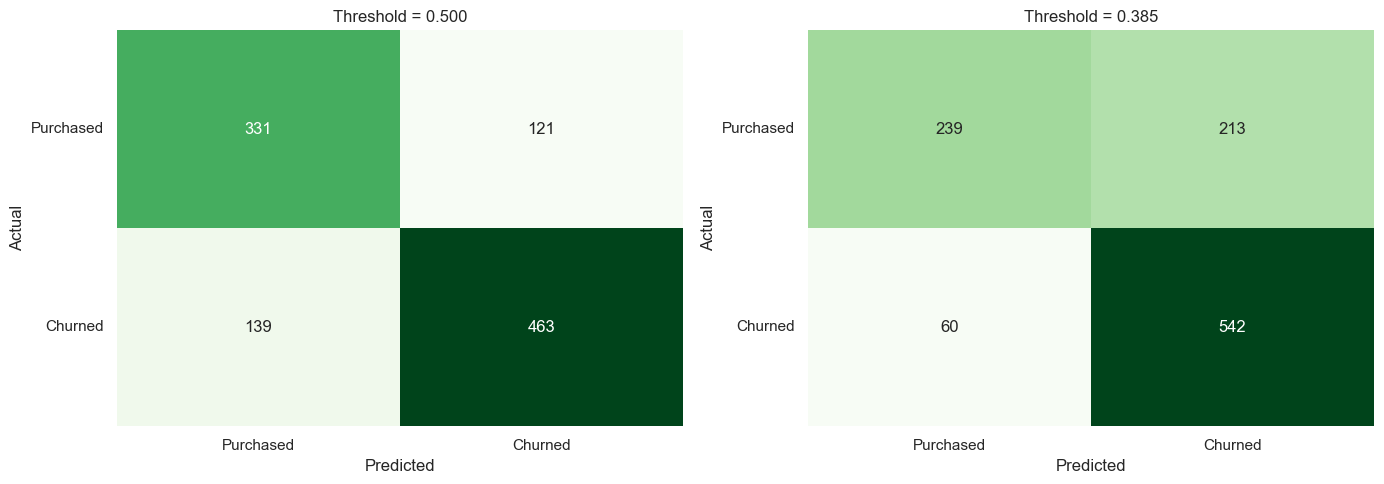

In [20]:
y_test_proba = best_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)
f1_scores = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
optimal_idx = int(np.nanargmax(f1_scores)) if len(f1_scores) else 0
optimal_threshold = float(thresholds[optimal_idx]) if len(thresholds) else 0.5

plt.figure(figsize=(12, 6))
plt.plot(recall, precision, label="Precision-Recall curve")
plt.scatter(recall[optimal_idx], precision[optimal_idx], color="red", label=f"Best F1 threshold={optimal_threshold:.3f}")
plt.title(f"Precision-Recall Curve: {best_model_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

def threshold_metrics(threshold: float) -> dict:
    pred = (y_test_proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "precision_churn": precision_score(y_test, pred, pos_label=1, zero_division=0),
        "recall_churn": recall_score(y_test, pred, pos_label=1, zero_division=0),
        "f1_churn": f1_score(y_test, pred, pos_label=1, zero_division=0),
    }

threshold_comparison = pd.DataFrame([
    threshold_metrics(0.5),
    threshold_metrics(optimal_threshold),
])
display(threshold_comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, threshold in zip(axes, [0.5, optimal_threshold]):
    pred = (y_test_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax)
    ax.set_title(f"Threshold = {threshold:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(["Purchased", "Churned"])
    ax.set_yticklabels(["Purchased", "Churned"], rotation=0)

plt.tight_layout()
plt.show()

## 8. Batch Scoring Output (Preview)

Apply the selected model to the full customer feature matrix and create the batch scoring shape expected by downstream churn activation workflows.

In [21]:
scoring_features = features[["customer_id", *FEATURE_COLUMNS]].copy()
scoring_probabilities = best_model.predict_proba(scoring_features[FEATURE_COLUMNS])[:, 1]

scoring_df = pd.DataFrame(
    {
        "customer_id": scoring_features["customer_id"],
        "churn_probability": scoring_probabilities,
    }
)
scoring_df["churn_flag"] = (scoring_df["churn_probability"] >= optimal_threshold).astype(int)
scoring_df["risk_tier"] = np.select(
    [
        scoring_df["churn_probability"] >= 0.7,
        scoring_df["churn_probability"] >= 0.4,
    ],
    ["High", "Medium"],
    default="Low",
)

print(f"Scoring rows: {len(scoring_df):,}")
display(scoring_df.head(50))
display(scoring_df["risk_tier"].value_counts().rename_axis("risk_tier").reset_index(name="customers"))

Scoring rows: 5,268


,customer_id,churn_probability,churn_flag,risk_tier
0,12346,0.4038,1,Medium
1,12347,0.1769,0,Low
2,12348,0.5012,1,Medium
3,12349,0.4348,1,Medium
4,12350,0.6822,1,Medium
5,12351,0.6822,1,Medium
6,12352,0.4722,1,Medium
7,12353,0.5871,1,Medium
8,12354,0.5435,1,Medium
9,12355,0.6093,1,Medium


,risk_tier,customers
0,Medium,2403
1,Low,1617
2,High,1248
